In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import glorot_uniform
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.graph_objects as go

In [2]:
sales_df = pd.read_csv("sales_data_sample.csv",encoding = 'unicode_escape')

In [3]:
sales_df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [4]:
sales_df["ORDERDATE"] = pd.to_datetime(sales_df["ORDERDATE"])

In [5]:
sales_df["ORDERDATE"]

,ORDERDATE
0,2003-02-24
1,2003-05-07
2,2003-07-01
3,2003-08-25
4,2003-10-10
...,...
2818,2004-12-02
2819,2005-01-31
2820,2005-03-01
2821,2005-03-28


In [6]:
print(sales_df.isnull().sum())

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64


In [7]:
sales_df = sales_df.drop(['ADDRESSLINE1', 'ADDRESSLINE2', 'POSTALCODE', 'CITY', 'TERRITORY', 'PHONE', 'STATE', 'CONTACTFIRSTNAME', 'CONTACTLASTNAME', 'CUSTOMERNAME', 'ORDERNUMBER'],axis=1)
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,COUNTRY,DEALSIZE
0,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,Motorcycles,95,S10_1678,USA,Small
1,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,Motorcycles,95,S10_1678,France,Small
2,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,Motorcycles,95,S10_1678,France,Medium
3,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,Motorcycles,95,S10_1678,USA,Medium
4,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,Motorcycles,95,S10_1678,USA,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,Shipped,4,12,2004,Ships,54,S72_3212,Spain,Small
2819,29,100.00,1,3978.51,2005-01-31,Shipped,1,1,2005,Ships,54,S72_3212,Finland,Medium
2820,43,100.00,4,5417.57,2005-03-01,Resolved,1,3,2005,Ships,54,S72_3212,Spain,Medium
2821,34,62.24,1,2116.16,2005-03-28,Shipped,1,3,2005,Ships,54,S72_3212,France,Small


In [8]:
print(sales_df.isnull().sum())

QUANTITYORDERED    0
PRICEEACH          0
ORDERLINENUMBER    0
SALES              0
ORDERDATE          0
STATUS             0
QTR_ID             0
MONTH_ID           0
YEAR_ID            0
PRODUCTLINE        0
MSRP               0
PRODUCTCODE        0
COUNTRY            0
DEALSIZE           0
dtype: int64


In [9]:
sales_df['COUNTRY'].nunique()

19

In [10]:
def barplot_visualization(x):
  fig = plt.Figure(figsize = (12, 6))
  fig = px.bar(x = sales_df[x].value_counts().index, y = sales_df[x].value_counts(), color = sales_df[x].value_counts().index, height = 500)
  fig.show()

In [11]:
barplot_visualization("COUNTRY")

In [12]:
barplot_visualization("STATUS")

In [13]:
sales_df.drop(columns= ['STATUS'], inplace = True)
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,COUNTRY,DEALSIZE
0,30,95.70,2,2871.00,2003-02-24,1,2,2003,Motorcycles,95,S10_1678,USA,Small
1,34,81.35,5,2765.90,2003-05-07,2,5,2003,Motorcycles,95,S10_1678,France,Small
2,41,94.74,2,3884.34,2003-07-01,3,7,2003,Motorcycles,95,S10_1678,France,Medium
3,45,83.26,6,3746.70,2003-08-25,3,8,2003,Motorcycles,95,S10_1678,USA,Medium
4,49,100.00,14,5205.27,2003-10-10,4,10,2003,Motorcycles,95,S10_1678,USA,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,4,12,2004,Ships,54,S72_3212,Spain,Small
2819,29,100.00,1,3978.51,2005-01-31,1,1,2005,Ships,54,S72_3212,Finland,Medium
2820,43,100.00,4,5417.57,2005-03-01,1,3,2005,Ships,54,S72_3212,Spain,Medium
2821,34,62.24,1,2116.16,2005-03-28,1,3,2005,Ships,54,S72_3212,France,Small


In [14]:
def dummies(x):
  dummy = pd.get_dummies(sales_df[x])
  sales_df.drop(columns = x , inplace = True)
  return pd.concat([sales_df, dummy], axis = 1)

In [15]:
sales_df = dummies("COUNTRY")
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,...,Italy,Japan,Norway,Philippines,Singapore,Spain,Sweden,Switzerland,UK,USA
0,30,95.70,2,2871.00,2003-02-24,1,2,2003,Motorcycles,95,...,False,False,False,False,False,False,False,False,False,True
1,34,81.35,5,2765.90,2003-05-07,2,5,2003,Motorcycles,95,...,False,False,False,False,False,False,False,False,False,False
2,41,94.74,2,3884.34,2003-07-01,3,7,2003,Motorcycles,95,...,False,False,False,False,False,False,False,False,False,False
3,45,83.26,6,3746.70,2003-08-25,3,8,2003,Motorcycles,95,...,False,False,False,False,False,False,False,False,False,True
4,49,100.00,14,5205.27,2003-10-10,4,10,2003,Motorcycles,95,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,4,12,2004,Ships,54,...,False,False,False,False,False,True,False,False,False,False
2819,29,100.00,1,3978.51,2005-01-31,1,1,2005,Ships,54,...,False,False,False,False,False,False,False,False,False,False
2820,43,100.00,4,5417.57,2005-03-01,1,3,2005,Ships,54,...,False,False,False,False,False,True,False,False,False,False
2821,34,62.24,1,2116.16,2005-03-28,1,3,2005,Ships,54,...,False,False,False,False,False,False,False,False,False,False


In [16]:
sales_df = dummies("PRODUCTLINE")
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,...,Switzerland,UK,USA,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars
0,30,95.70,2,2871.00,2003-02-24,1,2,2003,95,S10_1678,...,False,False,True,False,True,False,False,False,False,False
1,34,81.35,5,2765.90,2003-05-07,2,5,2003,95,S10_1678,...,False,False,False,False,True,False,False,False,False,False
2,41,94.74,2,3884.34,2003-07-01,3,7,2003,95,S10_1678,...,False,False,False,False,True,False,False,False,False,False
3,45,83.26,6,3746.70,2003-08-25,3,8,2003,95,S10_1678,...,False,False,True,False,True,False,False,False,False,False
4,49,100.00,14,5205.27,2003-10-10,4,10,2003,95,S10_1678,...,False,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,4,12,2004,54,S72_3212,...,False,False,False,False,False,False,True,False,False,False
2819,29,100.00,1,3978.51,2005-01-31,1,1,2005,54,S72_3212,...,False,False,False,False,False,False,True,False,False,False
2820,43,100.00,4,5417.57,2005-03-01,1,3,2005,54,S72_3212,...,False,False,False,False,False,False,True,False,False,False
2821,34,62.24,1,2116.16,2005-03-28,1,3,2005,54,S72_3212,...,False,False,False,False,False,False,True,False,False,False


In [17]:
sales_df = dummies("DEALSIZE")
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,30,95.70,2,2871.00,2003-02-24,1,2,2003,95,S10_1678,...,False,True,False,False,False,False,False,False,False,True
1,34,81.35,5,2765.90,2003-05-07,2,5,2003,95,S10_1678,...,False,True,False,False,False,False,False,False,False,True
2,41,94.74,2,3884.34,2003-07-01,3,7,2003,95,S10_1678,...,False,True,False,False,False,False,False,False,True,False
3,45,83.26,6,3746.70,2003-08-25,3,8,2003,95,S10_1678,...,False,True,False,False,False,False,False,False,True,False
4,49,100.00,14,5205.27,2003-10-10,4,10,2003,95,S10_1678,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,4,12,2004,54,S72_3212,...,False,False,False,True,False,False,False,False,False,True
2819,29,100.00,1,3978.51,2005-01-31,1,1,2005,54,S72_3212,...,False,False,False,True,False,False,False,False,True,False
2820,43,100.00,4,5417.57,2005-03-01,1,3,2005,54,S72_3212,...,False,False,False,True,False,False,False,False,True,False
2821,34,62.24,1,2116.16,2005-03-28,1,3,2005,54,S72_3212,...,False,False,False,True,False,False,False,False,False,True


In [18]:
sales_df['PRODUCTCODE'] = pd.Categorical(sales_df['PRODUCTCODE']).codes
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,30,95.70,2,2871.00,2003-02-24,1,2,2003,95,0,...,False,True,False,False,False,False,False,False,False,True
1,34,81.35,5,2765.90,2003-05-07,2,5,2003,95,0,...,False,True,False,False,False,False,False,False,False,True
2,41,94.74,2,3884.34,2003-07-01,3,7,2003,95,0,...,False,True,False,False,False,False,False,False,True,False
3,45,83.26,6,3746.70,2003-08-25,3,8,2003,95,0,...,False,True,False,False,False,False,False,False,True,False
4,49,100.00,14,5205.27,2003-10-10,4,10,2003,95,0,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,4,12,2004,54,108,...,False,False,False,True,False,False,False,False,False,True
2819,29,100.00,1,3978.51,2005-01-31,1,1,2005,54,108,...,False,False,False,True,False,False,False,False,True,False
2820,43,100.00,4,5417.57,2005-03-01,1,3,2005,54,108,...,False,False,False,True,False,False,False,False,True,False
2821,34,62.24,1,2116.16,2005-03-28,1,3,2005,54,108,...,False,False,False,True,False,False,False,False,False,True


In [19]:
sales_df_group = sales_df.groupby(by = "ORDERDATE").sum()
sales_df_group

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
ORDERDATE,,,,,,,,,,,,,,,,,,,,,
2003-01-06,151,288.78,10,12133.25,4,4,8012,363,174,0,...,0,0,0,0,0,0,4,0,2,2
2003-01-09,142,284.96,10,11432.34,4,4,8012,372,181,0,...,0,0,0,0,0,0,4,0,2,2
2003-01-10,80,150.14,3,6864.05,2,2,4006,155,37,0,...,0,0,0,0,0,0,2,0,1,1
2003-01-29,541,1417.54,136,54702.00,16,16,32048,1695,723,0,...,3,0,0,0,0,7,6,0,10,6
2003-01-31,443,1061.89,91,44621.96,13,13,26039,1365,720,0,...,7,0,0,0,2,4,0,0,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-05-13,259,561.18,21,31821.90,12,30,12030,728,101,0,...,0,6,0,0,0,0,0,2,3,1
2005-05-17,509,1269.43,105,59475.10,28,70,28070,1669,462,0,...,14,0,0,0,0,0,0,2,8,4
2005-05-29,607,1148.40,94,51233.18,30,75,30075,1328,797,13,...,7,0,0,0,0,0,8,0,8,7


In [20]:
fig = px.line(x = sales_df_group.index, y = sales_df_group.SALES, title = 'Sales')
fig.show()

In [21]:
sales_df.drop(columns= ['ORDERDATE'], inplace = True)
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,30,95.70,2,2871.00,1,2,2003,95,0,False,...,False,True,False,False,False,False,False,False,False,True
1,34,81.35,5,2765.90,2,5,2003,95,0,False,...,False,True,False,False,False,False,False,False,False,True
2,41,94.74,2,3884.34,3,7,2003,95,0,False,...,False,True,False,False,False,False,False,False,True,False
3,45,83.26,6,3746.70,3,8,2003,95,0,False,...,False,True,False,False,False,False,False,False,True,False
4,49,100.00,14,5205.27,4,10,2003,95,0,False,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,4,12,2004,54,108,False,...,False,False,False,True,False,False,False,False,False,True
2819,29,100.00,1,3978.51,1,1,2005,54,108,False,...,False,False,False,True,False,False,False,False,True,False
2820,43,100.00,4,5417.57,1,3,2005,54,108,False,...,False,False,False,True,False,False,False,False,True,False
2821,34,62.24,1,2116.16,1,3,2005,54,108,False,...,False,False,False,True,False,False,False,False,False,True


In [22]:
sales_df.corr()

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
QUANTITYORDERED,1.000000,0.005564,-0.018397,0.551426,-0.035323,-0.039048,0.069535,0.017881,-0.005400,-0.036180,...,0.004388,0.005345,-0.001334,-0.011175,0.002200,0.025226,-0.020568,0.302231,0.287417,-0.427695
PRICEEACH,0.005564,1.000000,-0.020965,0.657841,0.008712,0.005152,-0.005938,0.670625,-0.276001,-0.001965,...,0.131591,-0.011943,-0.033148,0.002935,-0.066447,0.066272,-0.142977,0.194191,0.569012,-0.660698
ORDERLINENUMBER,-0.018397,-0.020965,1.000000,-0.058400,0.040716,0.034016,-0.057367,-0.021067,0.034087,-0.005164,...,-0.003496,-0.046205,0.062393,0.023693,0.026819,-0.019917,-0.018564,-0.062992,-0.010596,0.039634
SALES,0.551426,0.657841,-0.058400,1.000000,-0.006796,-0.009605,0.035647,0.635239,-0.335955,-0.020868,...,0.195780,-0.005949,-0.069601,-0.081747,-0.055983,0.036192,-0.118953,0.624604,0.449758,-0.739079
QTR_ID,-0.035323,0.008712,0.040716,-0.006796,1.000000,0.979300,-0.433052,0.010234,-0.017200,0.009787,...,0.034732,-0.014225,-0.029923,-0.018077,-0.000472,0.018098,-0.007614,-0.018845,0.002199,0.006466
MONTH_ID,-0.039048,0.005152,0.034016,-0.009605,0.979300,1.000000,-0.430163,0.008170,-0.011870,0.012880,...,0.029522,-0.021865,-0.027829,-0.013225,0.001714,0.023599,-0.005453,-0.021357,0.003303,0.006514
YEAR_ID,0.069535,-0.005938,-0.057367,0.035647,-0.433052,-0.430163,1.000000,-0.014310,0.024560,0.000426,...,-0.030082,0.016062,0.051443,0.000494,-0.005478,-0.008765,-0.008332,0.033211,-0.012241,-0.002996
MSRP,0.017881,0.670625,-0.021067,0.635239,0.010234,0.008170,-0.014310,1.000000,-0.544184,-0.004965,...,0.344366,-0.033071,-0.103677,-0.109144,-0.115559,0.015043,-0.185667,0.347085,0.369366,-0.530621
PRODUCTCODE,-0.005400,-0.276001,0.034087,-0.335955,-0.017200,-0.011870,0.024560,-0.544184,1.000000,-0.044742,...,-0.294297,-0.074856,0.285963,0.338570,0.106014,-0.035245,-0.060596,-0.211562,-0.162348,0.260385
Australia,-0.036180,-0.001965,-0.005164,-0.020868,0.009787,0.012880,0.000426,-0.004965,-0.044742,1.000000,...,-0.031281,0.019170,0.022778,-0.069231,-0.035557,0.001273,0.063488,-0.020541,-0.013452,0.022962


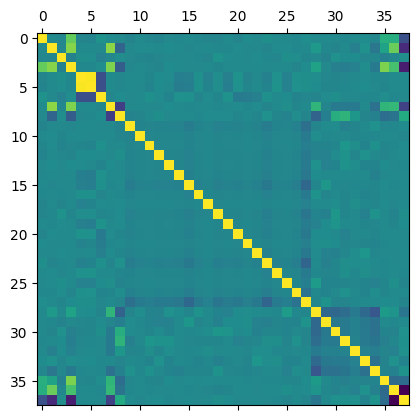

In [23]:
plt.matshow(sales_df.corr())
plt.show()

<Axes: >

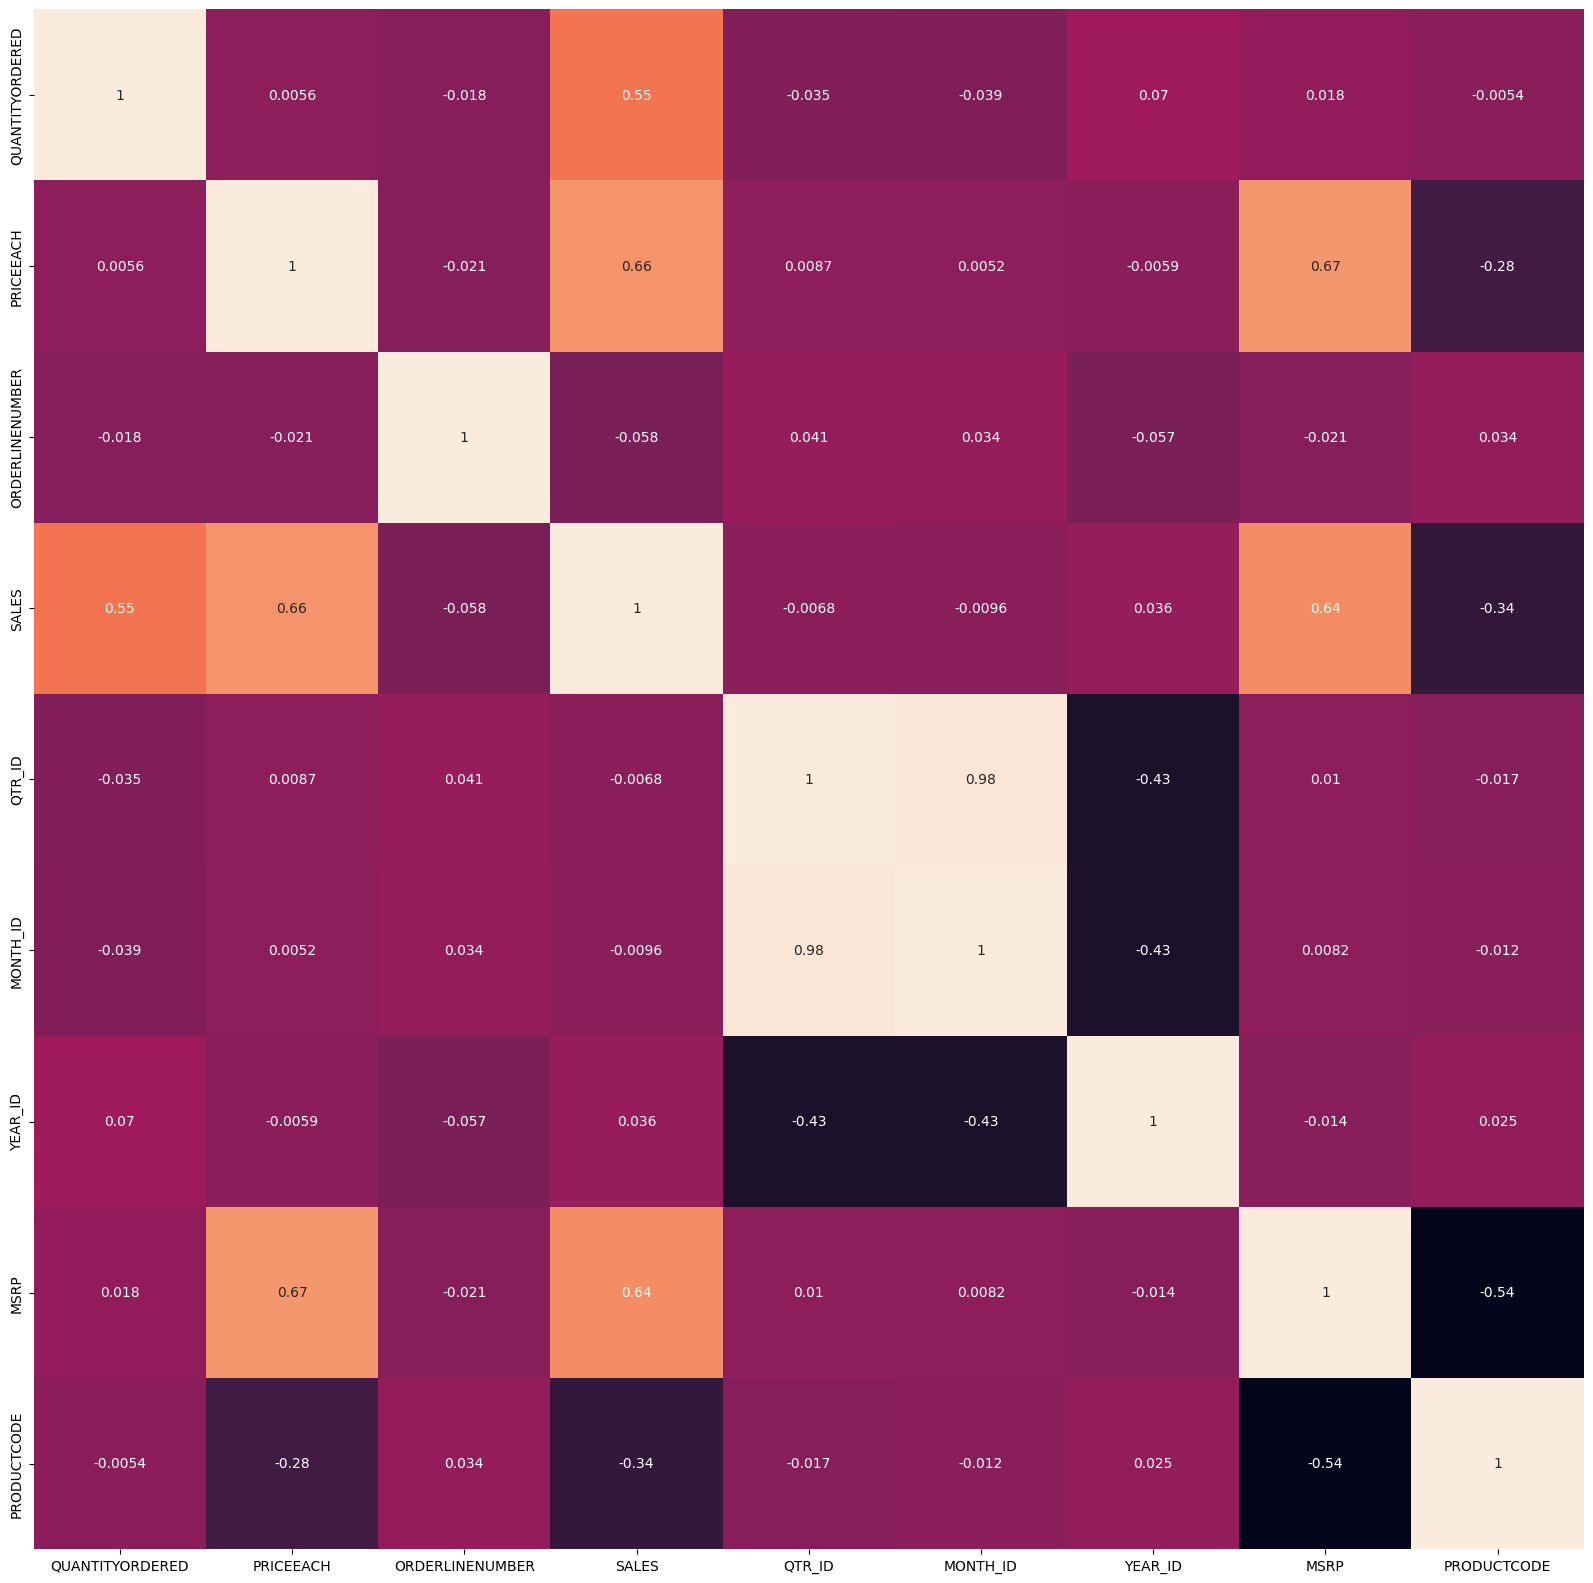

In [24]:
plt.figure(figsize = (20, 20))
sns.heatmap(sales_df.iloc[:, :9].corr(), annot = True,cbar=False)

In [25]:
sales_df.drop(columns= ['QTR_ID'], inplace = True)
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,30,95.70,2,2871.00,2,2003,95,0,False,False,...,False,True,False,False,False,False,False,False,False,True
1,34,81.35,5,2765.90,5,2003,95,0,False,False,...,False,True,False,False,False,False,False,False,False,True
2,41,94.74,2,3884.34,7,2003,95,0,False,False,...,False,True,False,False,False,False,False,False,True,False
3,45,83.26,6,3746.70,8,2003,95,0,False,False,...,False,True,False,False,False,False,False,False,True,False
4,49,100.00,14,5205.27,10,2003,95,0,False,False,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,12,2004,54,108,False,False,...,False,False,False,True,False,False,False,False,False,True
2819,29,100.00,1,3978.51,1,2005,54,108,False,False,...,False,False,False,True,False,False,False,False,True,False
2820,43,100.00,4,5417.57,3,2005,54,108,False,False,...,False,False,False,True,False,False,False,False,True,False
2821,34,62.24,1,2116.16,3,2005,54,108,False,False,...,False,False,False,True,False,False,False,False,False,True


In [29]:
scaler = StandardScaler()
sales_df_scaled = scaler.fit_transform(sales_df)

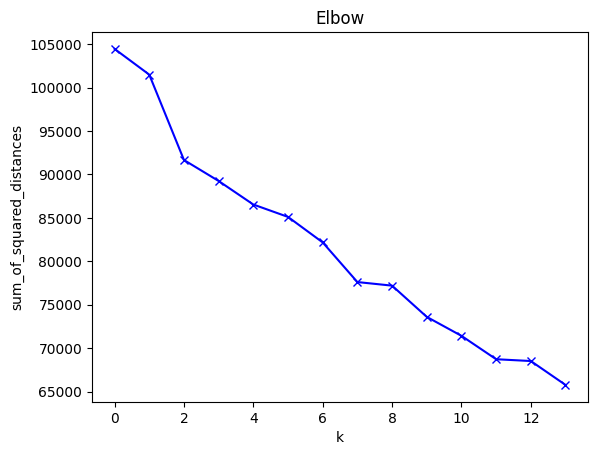

In [30]:
sum_of_squared_distances = []
K = range(1,15)
for k in K:
    km = KMeans(k)
    km.fit(sales_df_scaled)
    sum_of_squared_distances.append(km.inertia_)
plt.plot(sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('sum_of_squared_distances')
plt.title('Elbow')
plt.show()

In [31]:
kmean = KMeans(n_clusters = 7)
kmean.fit(sales_df_scaled)
labels = kmean.labels_

In [33]:
print(labels)
print(kmean.cluster_centers_)
print(kmean.cluster_centers_.shape)

[0 0 2 ... 2 0 2]
[[-4.38095172e-01 -7.74031057e-01  2.05884171e-02 -8.18746067e-01
  -1.55951649e-02 -4.84435188e-02 -6.81986586e-01  2.67629828e-01
   8.38645504e-02  3.96483053e-03 -1.08756411e-01  8.82581495e-02
  -1.54752317e-02 -1.86621112e-02  9.21917200e-02 -3.42062461e-02
   2.71268493e-02  6.30527106e-02  4.63555216e-02 -2.29134503e-02
   3.65680978e-04  4.51998311e-02 -3.71278389e-01 -1.43552692e-01
  -1.05371495e-01  5.52890736e-02  1.55087952e-01 -7.21812255e-01
   3.49164064e-01 -3.48673632e-01  2.19090240e-01  2.20387783e-01
   1.38793643e-01  4.85508587e-01 -2.42672047e-01 -9.80703326e-01
   1.09637041e+00]
 [-4.52986253e-01 -7.90539172e-01  5.97632801e-02 -8.26075491e-01
   9.04579639e-02 -2.96822250e-02 -4.81492649e-01  6.55699884e-02
  -5.46489733e-02 -5.54391214e-02 -1.08756411e-01 -1.13850000e-01
   4.09725385e-02 -1.04561201e-02 -7.55647277e-02  4.37111286e-02
  -4.40073728e-02 -4.74196937e-02 -1.36988279e-01  3.64591369e-03
  -2.21705034e-02  3.09984302e-02  6.43

In [36]:
cluster_centers = scaler.inverse_transform(kmean.cluster_centers_)
cluster_centers = pd.DataFrame(data = cluster_centers, columns = [sales_df.columns])
cluster_centers

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,30.825886,68.045794,6.553159,2046.136379,7.035439,2003.781202,73.312789,62.224961,8.628659e-02,2.003082e-02,...,3.774758e-15,2.295840e-01,1.040834e-15,1.432974e-01,6.317411e-02,1.494607e-01,4.144838e-01,6.938894e-16,-1.110223e-15,1.000000e+00
1,30.680851,67.712813,6.718676,2032.638960,7.423168,2003.794326,81.368794,55.843972,5.200946e-02,1.182033e-02,...,7.848700e-01,1.654846e-02,-2.775558e-17,5.200946e-02,1.654846e-02,4.255319e-02,8.747045e-02,3.677614e-16,-9.992007e-16,1.000000e+00
2,38.773263,94.452543,6.124509,4243.866750,6.920052,2003.837484,104.085190,53.803408,6.553080e-02,1.179554e-02,...,9.305374e-02,1.979030e-01,1.026956e-15,1.284404e-01,3.145478e-02,2.201835e-01,3.289646e-01,7.910339e-16,1.000000e+00,-1.276756e-15
3,32.545455,87.494242,4.969697,3285.230909,5.696970,2004.181818,101.060606,58.060606,1.387779e-17,1.040834e-17,...,1.212121e-01,5.551115e-17,3.030303e-02,3.333333e-01,9.090909e-02,5.551115e-17,4.242424e-01,4.857226e-17,4.545455e-01,5.454545e-01
4,35.192982,86.728246,5.912281,3684.459825,8.824561,2003.824561,104.789474,48.578947,2.775558e-17,1.387779e-17,...,2.982456e-01,5.263158e-02,5.263158e-02,1.754386e-01,1.754386e-02,1.929825e-01,2.105263e-01,3.508772e-02,5.438596e-01,4.210526e-01
5,38.343333,98.607650,6.341667,5596.406817,7.225000,2003.758333,145.820000,29.965000,5.333333e-02,3.833333e-02,...,9.050000e-01,3.500000e-02,6.666667e-03,1.124101e-15,1.666667e-03,1.166667e-02,4.000000e-02,2.483333e-01,7.483333e-01,3.333333e-03
6,34.942953,81.547416,7.315436,3122.613456,6.744966,2003.932886,87.597315,80.805369,8.389262e-02,1.677852e-02,...,-6.661338e-16,-8.326673e-16,1.000000e+00,4.440892e-16,-1.561251e-16,-3.053113e-16,-4.996004e-16,2.013423e-02,4.228188e-01,5.570470e-01


In [37]:
y_kmeans = kmean.fit_predict(sales_df_scaled)
y_kmeans

array([1, 1, 5, ..., 2, 2, 2], dtype=int32)

In [38]:
sale_df_cluster = pd.concat([sales_df, pd.DataFrame({'cluster':labels})], axis = 1)
sale_df_cluster

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small,cluster
0,30,95.70,2,2871.00,2,2003,95,0,False,False,...,True,False,False,False,False,False,False,False,True,0
1,34,81.35,5,2765.90,5,2003,95,0,False,False,...,True,False,False,False,False,False,False,False,True,0
2,41,94.74,2,3884.34,7,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,2
3,45,83.26,6,3746.70,8,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,2
4,49,100.00,14,5205.27,10,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,12,2004,54,108,False,False,...,False,False,True,False,False,False,False,False,True,1
2819,29,100.00,1,3978.51,1,2005,54,108,False,False,...,False,False,True,False,False,False,False,True,False,2
2820,43,100.00,4,5417.57,3,2005,54,108,False,False,...,False,False,True,False,False,False,False,True,False,2
2821,34,62.24,1,2116.16,3,2005,54,108,False,False,...,False,False,True,False,False,False,False,False,True,0


In [39]:
sale_df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   QUANTITYORDERED   2823 non-null   int64  
 1   PRICEEACH         2823 non-null   float64
 2   ORDERLINENUMBER   2823 non-null   int64  
 3   SALES             2823 non-null   float64
 4   MONTH_ID          2823 non-null   int64  
 5   YEAR_ID           2823 non-null   int64  
 6   MSRP              2823 non-null   int64  
 7   PRODUCTCODE       2823 non-null   int8   
 8   Australia         2823 non-null   bool   
 9   Austria           2823 non-null   bool   
 10  Belgium           2823 non-null   bool   
 11  Canada            2823 non-null   bool   
 12  Denmark           2823 non-null   bool   
 13  Finland           2823 non-null   bool   
 14  France            2823 non-null   bool   
 15  Germany           2823 non-null   bool   
 16  Ireland           2823 non-null   bool   


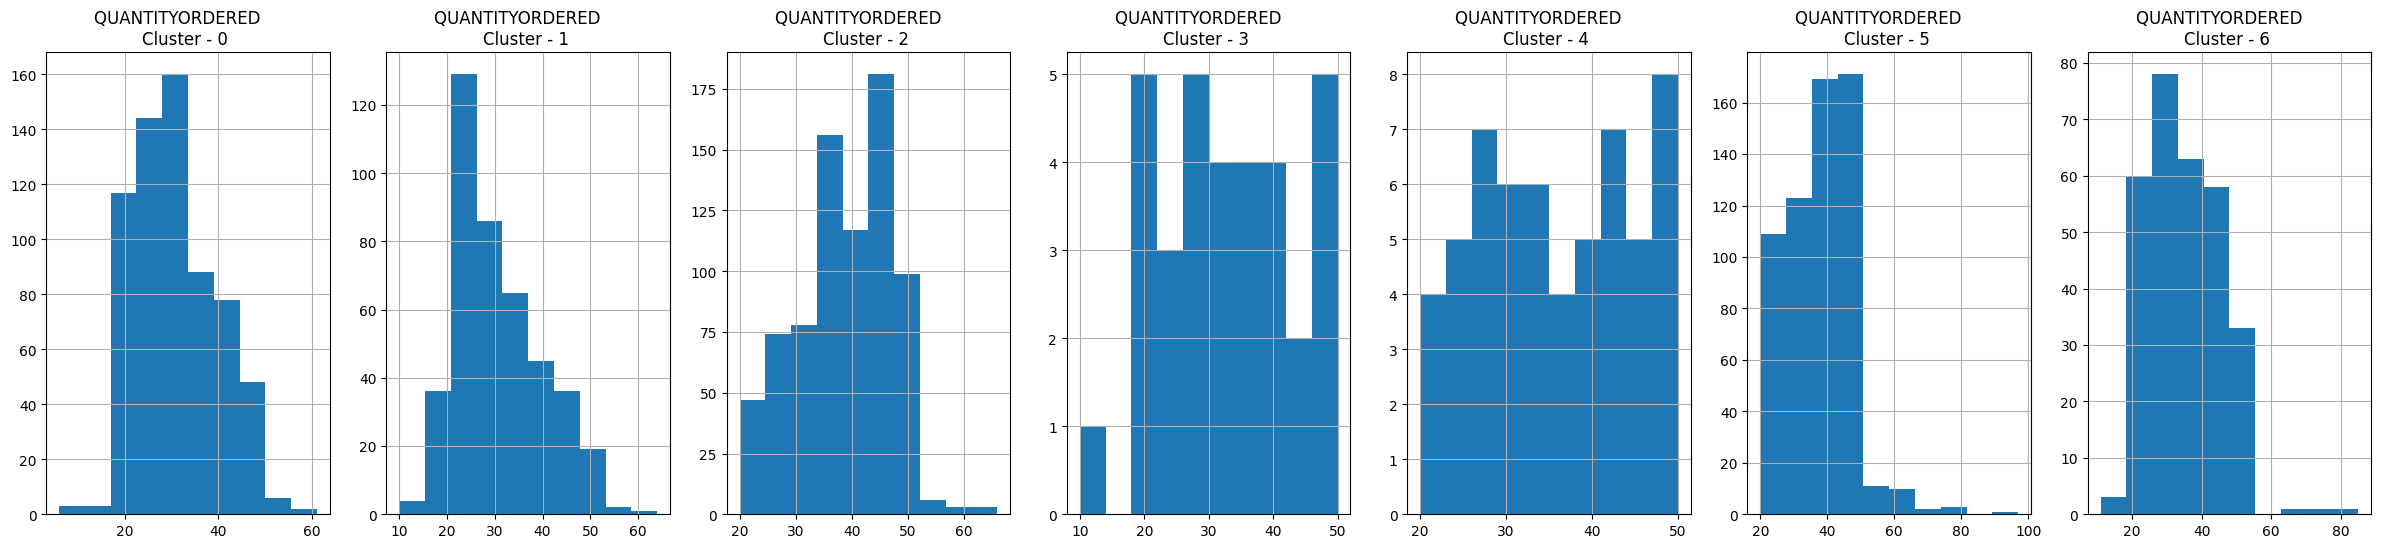

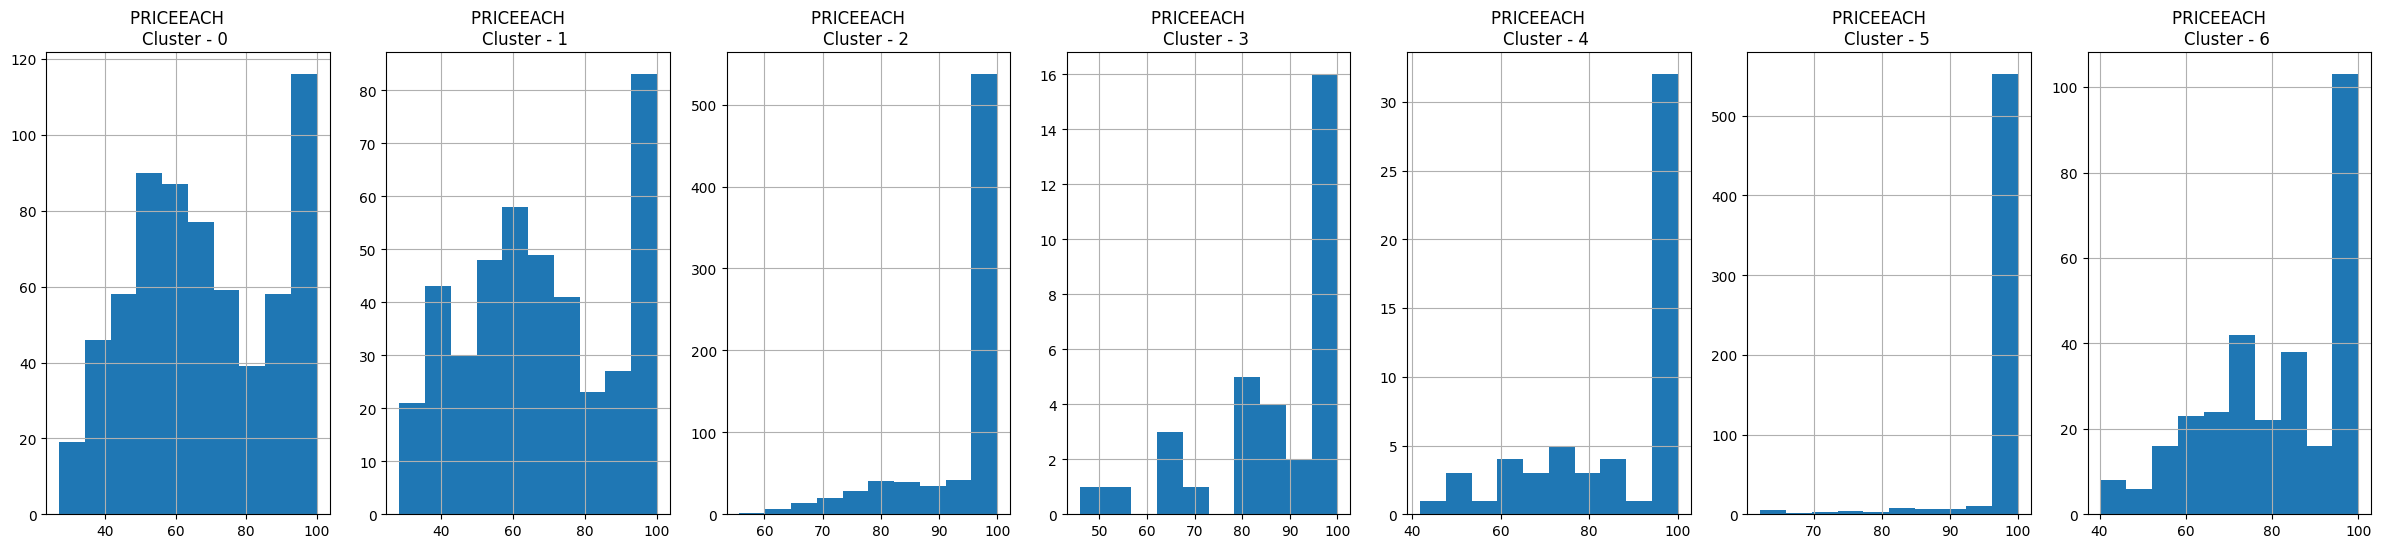

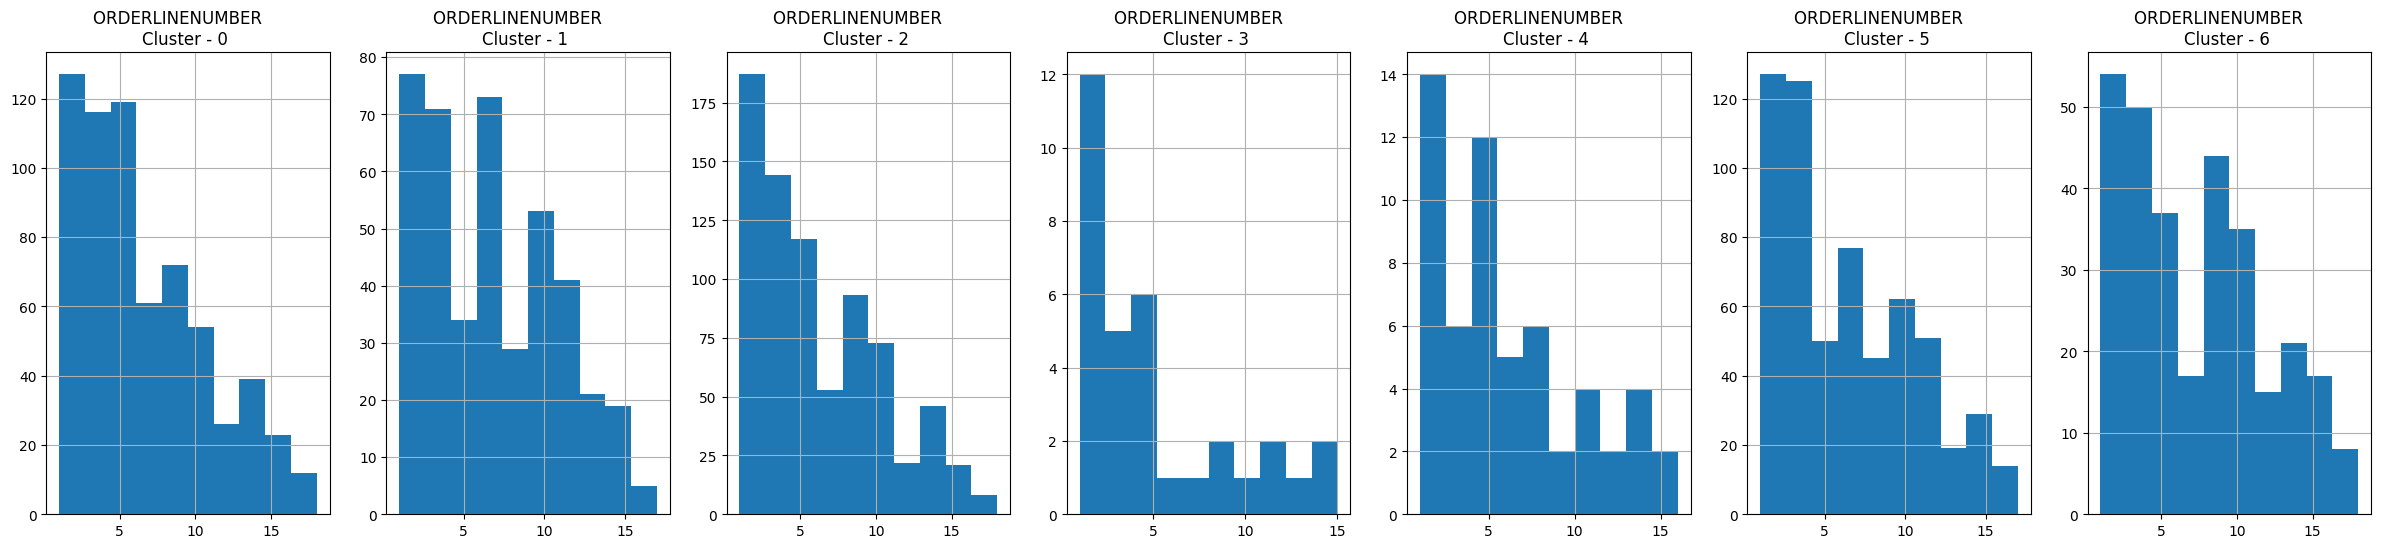

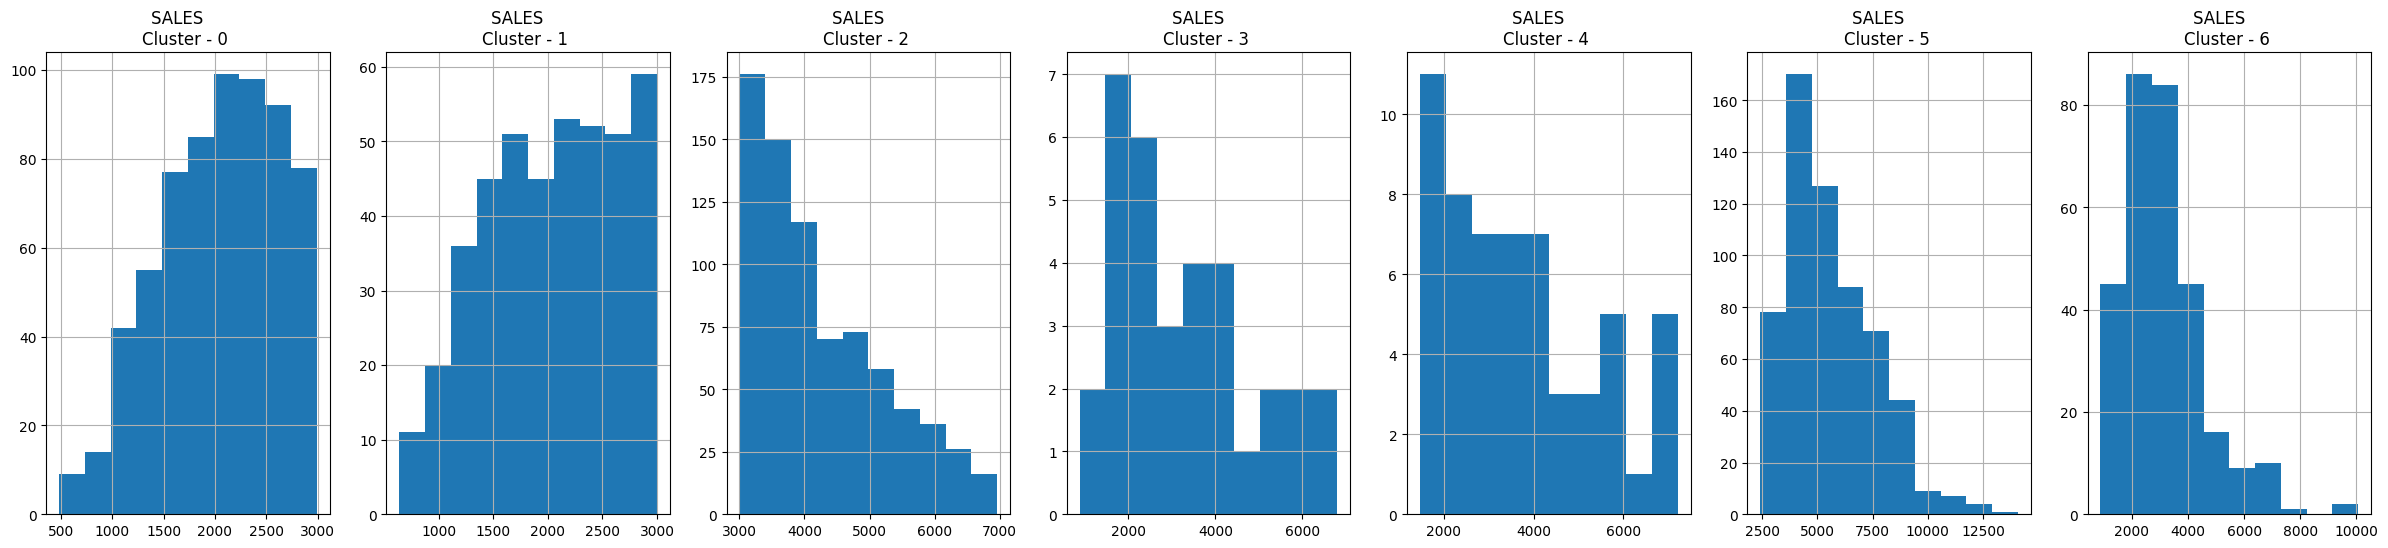

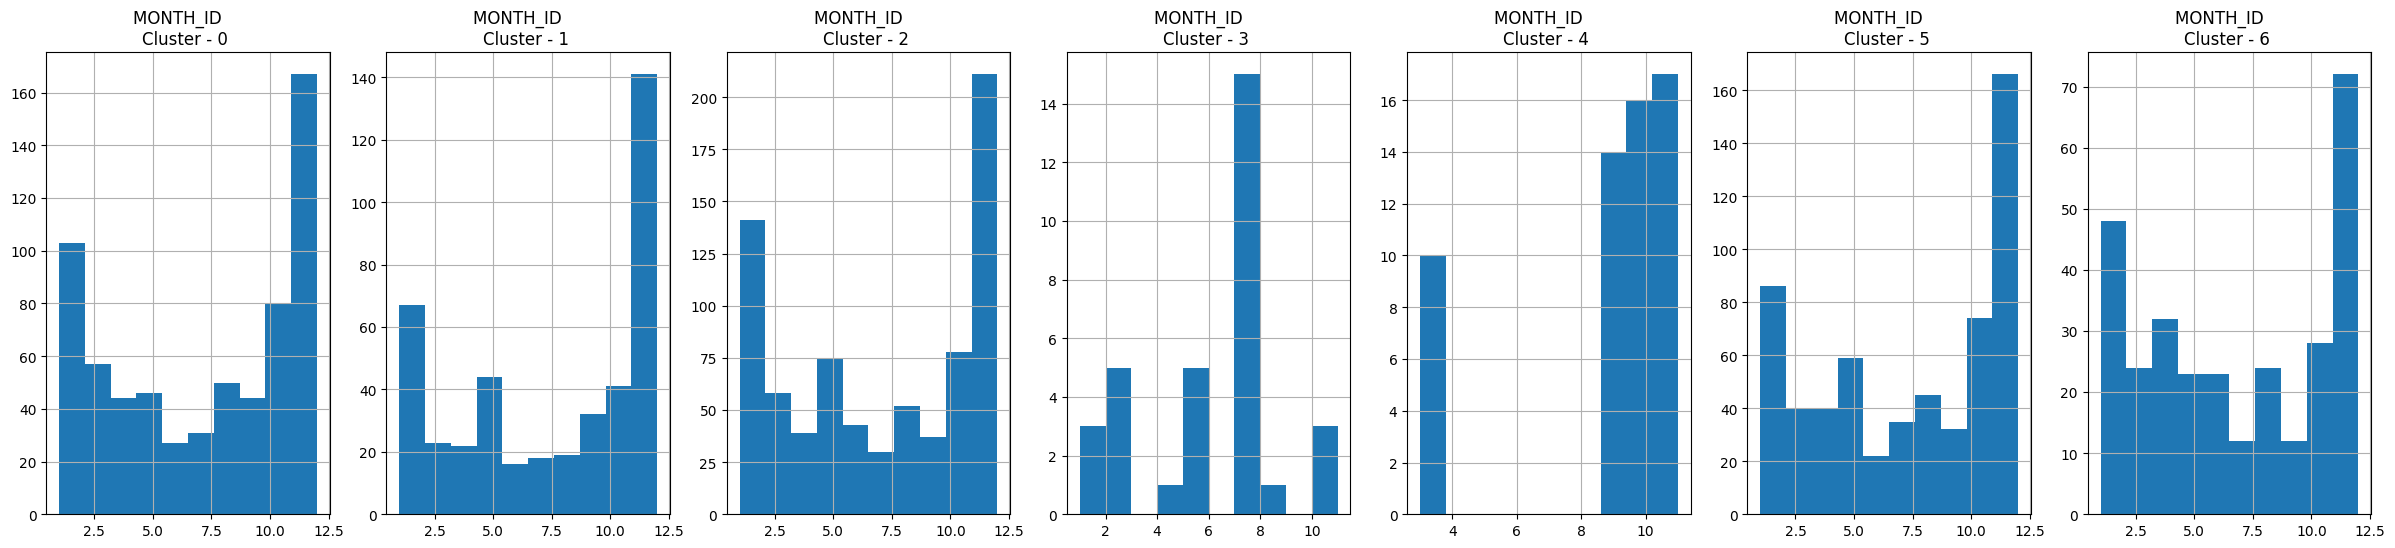

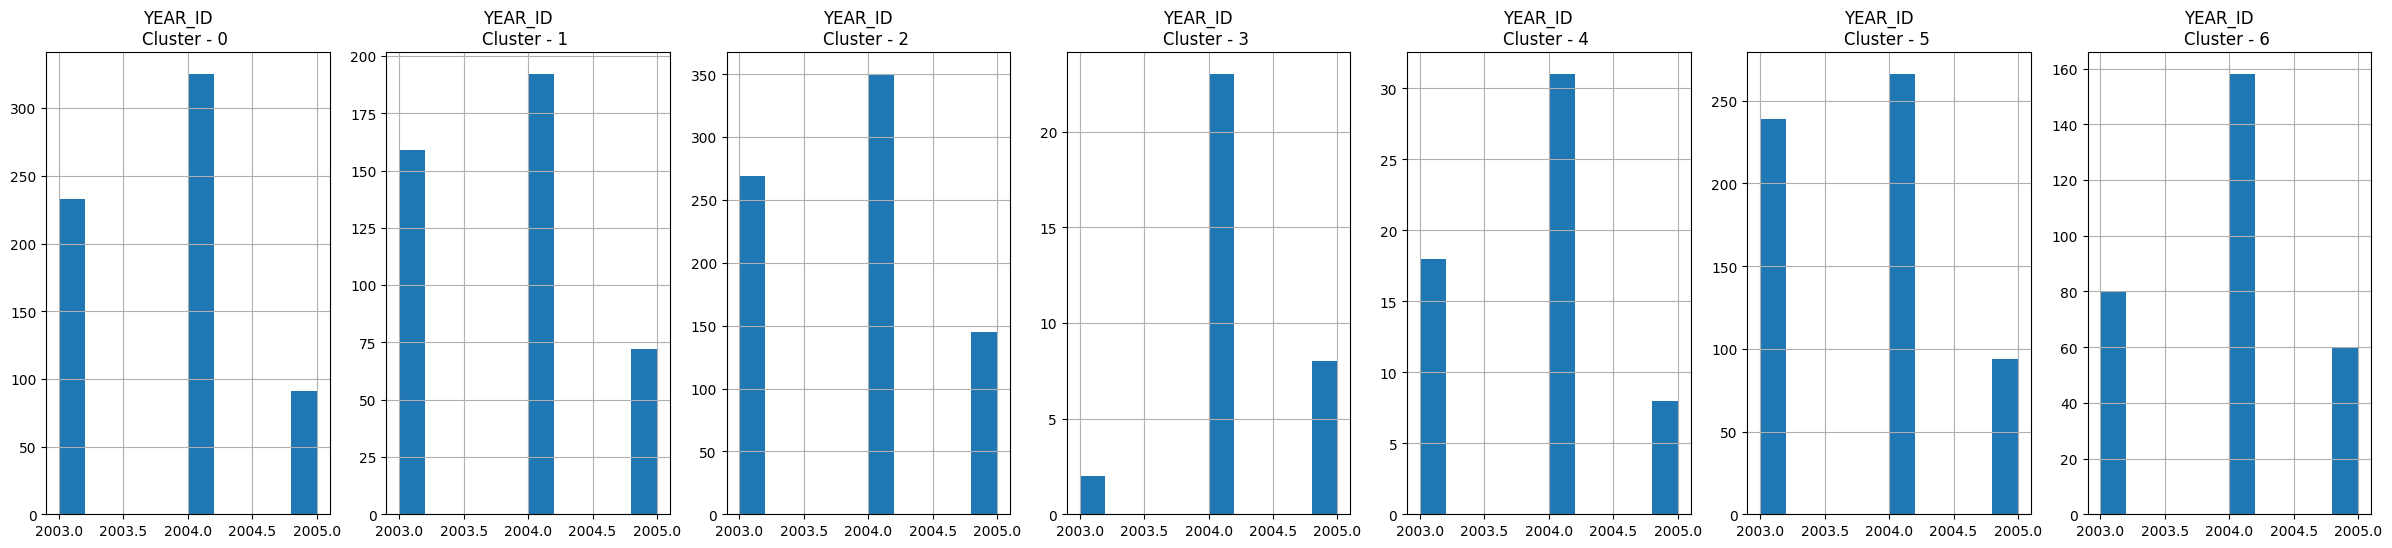

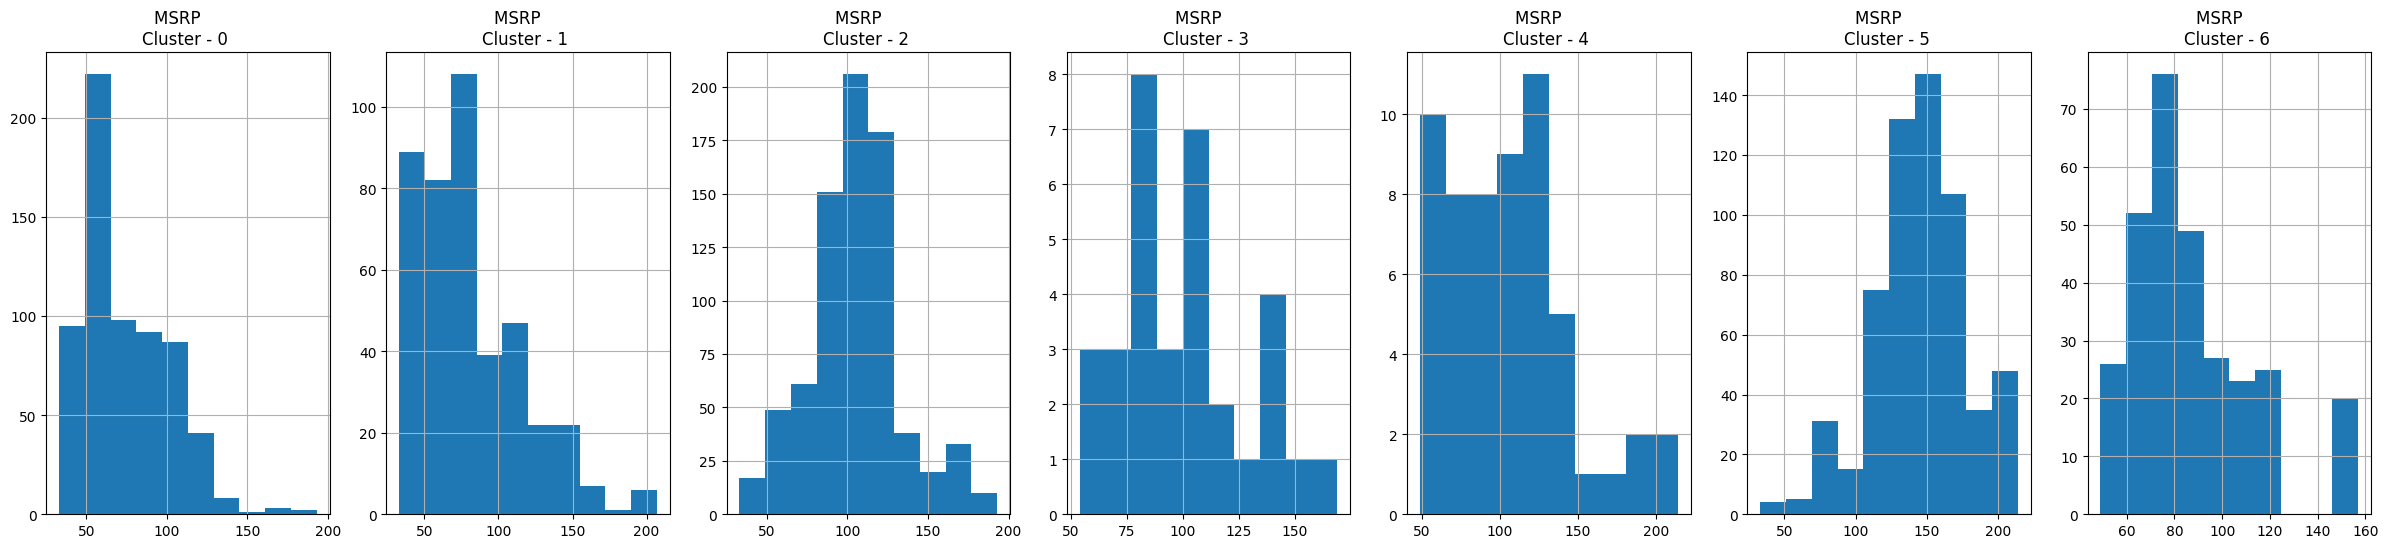

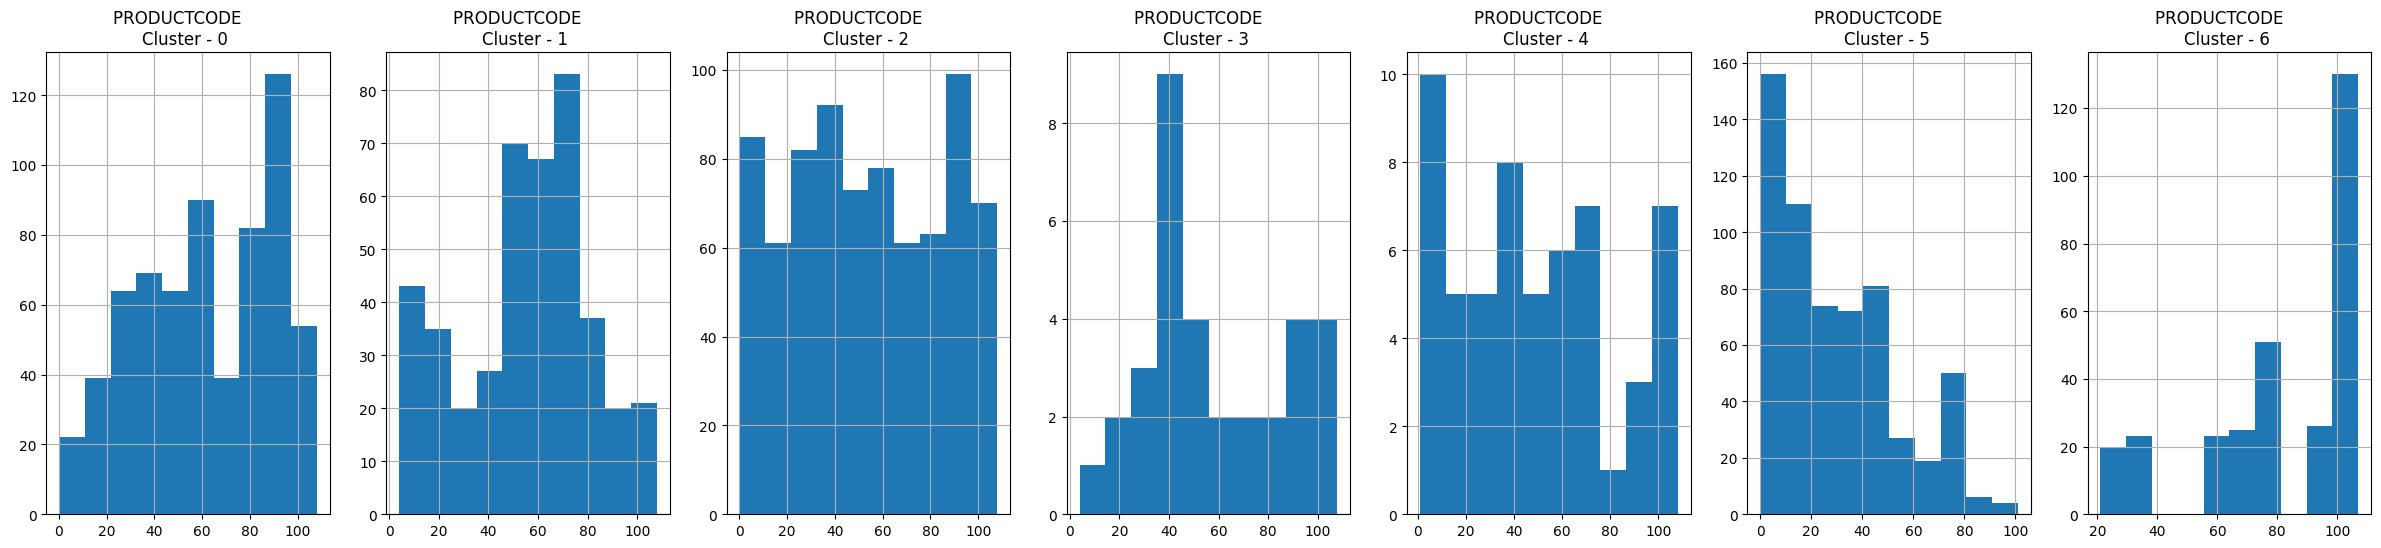

In [40]:
for i in sales_df.columns[:8]:
  plt.figure(figsize = (30, 6))
  for j in range(7):
    plt.subplot(1, 7, j+1)
    cluster = sale_df_cluster[sale_df_cluster['cluster'] == j]
    cluster[i].hist()
    plt.title('{}    \nCluster - {} '.format(i,j))

  plt.show()


In [41]:
pca = PCA(n_components = 3)
pca_sales = pca.fit_transform(sales_df_scaled)
pca_sales

array([[-0.48631933,  1.19523199, -1.00267727],
       [-0.78465471,  1.03283188, -1.4162651 ],
       [ 1.43146434, -0.12199648, -0.28129104],
       ...,
       [ 0.38985361, -4.12946409,  0.06056817],
       [-2.78886764, -2.38601395, -1.54986594],
       [-0.7054888 , -3.31242744,  0.51890644]])

In [52]:
pca_df = pd.DataFrame(data = pca_sales, columns = ['pca1', 'pca2', 'pca3'])
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster':labels.flatten()})], axis = 1)
pca_df

,pca1,pca2,pca3,cluster
0,-0.486319,1.195232,-1.002677,0
1,-0.784655,1.032832,-1.416265,0
2,1.431464,-0.121996,-0.281291,2
3,1.288425,0.218280,0.579360,2
4,1.976022,0.141698,1.061314,2
...,...,...,...,...
2818,-2.450314,-1.113172,1.523553,1
2819,-0.158247,-3.709748,-0.640182,2
2820,0.389854,-4.129464,0.060568,2
2821,-2.788868,-2.386014,-1.549866,0


In [56]:
fig = px.scatter_3d(pca_df, x = 'pca1', y = 'pca2', z = 'pca3', color = 'cluster', symbol = 'cluster', size_max = 18, opacity = 0.7)
fig.update_layout(margin = dict(l = 0, r = 0, b = 0, t = 0))

In [64]:
pca = PCA(n_components = 2)
pca_sales_2 = pca.fit_transform(sales_df_scaled)
pca_sales_2
pca_df_2 = pd.DataFrame(data = pca_sales_2, columns = ['pca1', 'pca2'])
pca_df_2 = pd.concat([pca_df_2, pd.DataFrame({'cluster':labels.flatten()})], axis = 1)
pca_df_2

,pca1,pca2,cluster
0,-0.486319,1.195232,0
1,-0.784655,1.032832,0
2,1.431464,-0.121996,2
3,1.288425,0.218280,2
4,1.976022,0.141698,2
...,...,...,...
2818,-2.450314,-1.113172,1
2819,-0.158247,-3.709748,2
2820,0.389854,-4.129464,2
2821,-2.788868,-2.386014,0


In [67]:
fig = px.scatter(pca_df, x = 'pca1', y = 'pca2', color = 'cluster', symbol = 'cluster', size_max = 18, opacity = 0.7)
fig.update_layout(margin = dict(l = 0, r = 0, b = 0, t = 0))

In [68]:
sales_df.shape

(2823, 37)

In [73]:
input_df = Input(shape = (37,))

x = Dense(50, activation = 'relu')(input_df)
x = Dense(500, activation = 'relu', kernel_initializer = 'glorot_uniform')(x)
x = Dense(500, activation = 'relu', kernel_initializer = 'glorot_uniform')(x)
x = Dense(2000, activation = 'relu', kernel_initializer = 'glorot_uniform')(x)
encoded = Dense(8, activation = 'relu', kernel_initializer = 'glorot_uniform')(x)

x = Dense(2000, activation = 'relu', kernel_initializer = 'glorot_uniform')(encoded)
x = Dense(500, activation = 'relu', kernel_initializer = 'glorot_uniform')(x)
x = Dense(500, activation = 'relu', kernel_initializer = 'glorot_uniform')(x)
x = Dense(50, activation = 'relu', kernel_initializer = 'glorot_uniform')(x)
decoded = Dense(37, kernel_initializer = 'glorot_uniform')(x)


autoencoder = Model(input_df, decoded)

encoder = Model(input_df, encoded)

autoencoder.compile(optimizer = 'adam', loss = 'mean_squared_error')
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 37)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 50)             │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 500)            │        25,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 2000)           │     1,002,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 8)              │        16,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 2000)           │        18,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 500)            │     1,000,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 50)             │        25,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 37)             │         1,887 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,845 (9.89 MB)

 Trainable params: 2,591,845 (9.89 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
autoencoder.fit(sales_df, sales_df,batch_size = 64 ,epochs = 1000,verbose=3)

Epoch 1/1000
Epoch 2/1000
Epoch 3/1000
Epoch 4/1000
Epoch 5/1000
Epoch 6/1000
Epoch 7/1000
Epoch 8/1000
Epoch 9/1000
Epoch 10/1000
Epoch 11/1000
Epoch 12/1000
Epoch 13/1000
Epoch 14/1000
Epoch 15/1000
Epoch 16/1000
Epoch 17/1000
Epoch 18/1000
Epoch 19/1000
Epoch 20/1000
Epoch 21/1000
Epoch 22/1000
Epoch 23/1000
Epoch 24/1000
Epoch 25/1000
Epoch 26/1000
Epoch 27/1000
Epoch 28/1000
Epoch 29/1000
Epoch 30/1000
Epoch 31/1000
Epoch 32/1000
Epoch 33/1000
Epoch 34/1000
Epoch 35/1000
Epoch 36/1000
Epoch 37/1000
Epoch 38/1000
Epoch 39/1000
Epoch 40/1000
Epoch 41/1000
Epoch 42/1000
Epoch 43/1000
Epoch 44/1000
Epoch 45/1000
Epoch 46/1000
Epoch 47/1000
Epoch 48/1000
Epoch 49/1000
Epoch 50/1000
Epoch 51/1000
Epoch 52/1000
Epoch 53/1000
Epoch 54/1000
Epoch 55/1000
Epoch 56/1000
Epoch 57/1000
Epoch 58/1000
Epoch 59/1000
Epoch 60/1000
Epoch 61/1000
Epoch 62/1000
Epoch 63/1000
Epoch 64/1000
Epoch 65/1000
Epoch 66/1000
Epoch 67/1000
Epoch 68/1000
Epoch 69/1000
Epoch 70/1000
Epoch 71/1000
Epoch 72/1000
E

In [75]:
pred = encoder.predict(sales_df_scaled)

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


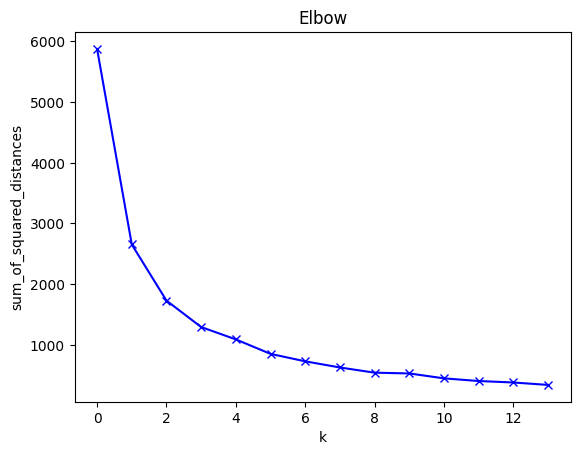

In [76]:
sum_of_squared_distances = []
K = range(1,15)
for k in K:
    km = KMeans(k)
    km.fit(pred)
    sum_of_squared_distances.append(km.inertia_)
plt.plot(sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('sum_of_squared_distances')
plt.title('Elbow')
plt.show()

In [82]:
kmean = KMeans(n_clusters = 3)
kmean.fit(sales_df_scaled)
labels = kmean.labels_

In [83]:
cluster_centers = scaler.inverse_transform(kmean.cluster_centers_)
cluster_centers = pd.DataFrame(data = cluster_centers, columns = [sales_df.columns])

In [84]:
y_kmeans = kmean.fit_predict(sales_df_scaled)

In [85]:
sale_df_cluster = pd.concat([sales_df, pd.DataFrame({'cluster':labels})], axis = 1)
sale_df_cluster

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small,cluster
0,30,95.70,2,2871.00,2,2003,95,0,False,False,...,True,False,False,False,False,False,False,False,True,2
1,34,81.35,5,2765.90,5,2003,95,0,False,False,...,True,False,False,False,False,False,False,False,True,2
2,41,94.74,2,3884.34,7,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,1
3,45,83.26,6,3746.70,8,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,1
4,49,100.00,14,5205.27,10,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,12,2004,54,108,False,False,...,False,False,True,False,False,False,False,False,True,2
2819,29,100.00,1,3978.51,1,2005,54,108,False,False,...,False,False,True,False,False,False,False,True,False,1
2820,43,100.00,4,5417.57,3,2005,54,108,False,False,...,False,False,True,False,False,False,False,True,False,1
2821,34,62.24,1,2116.16,3,2005,54,108,False,False,...,False,False,True,False,False,False,False,False,True,2


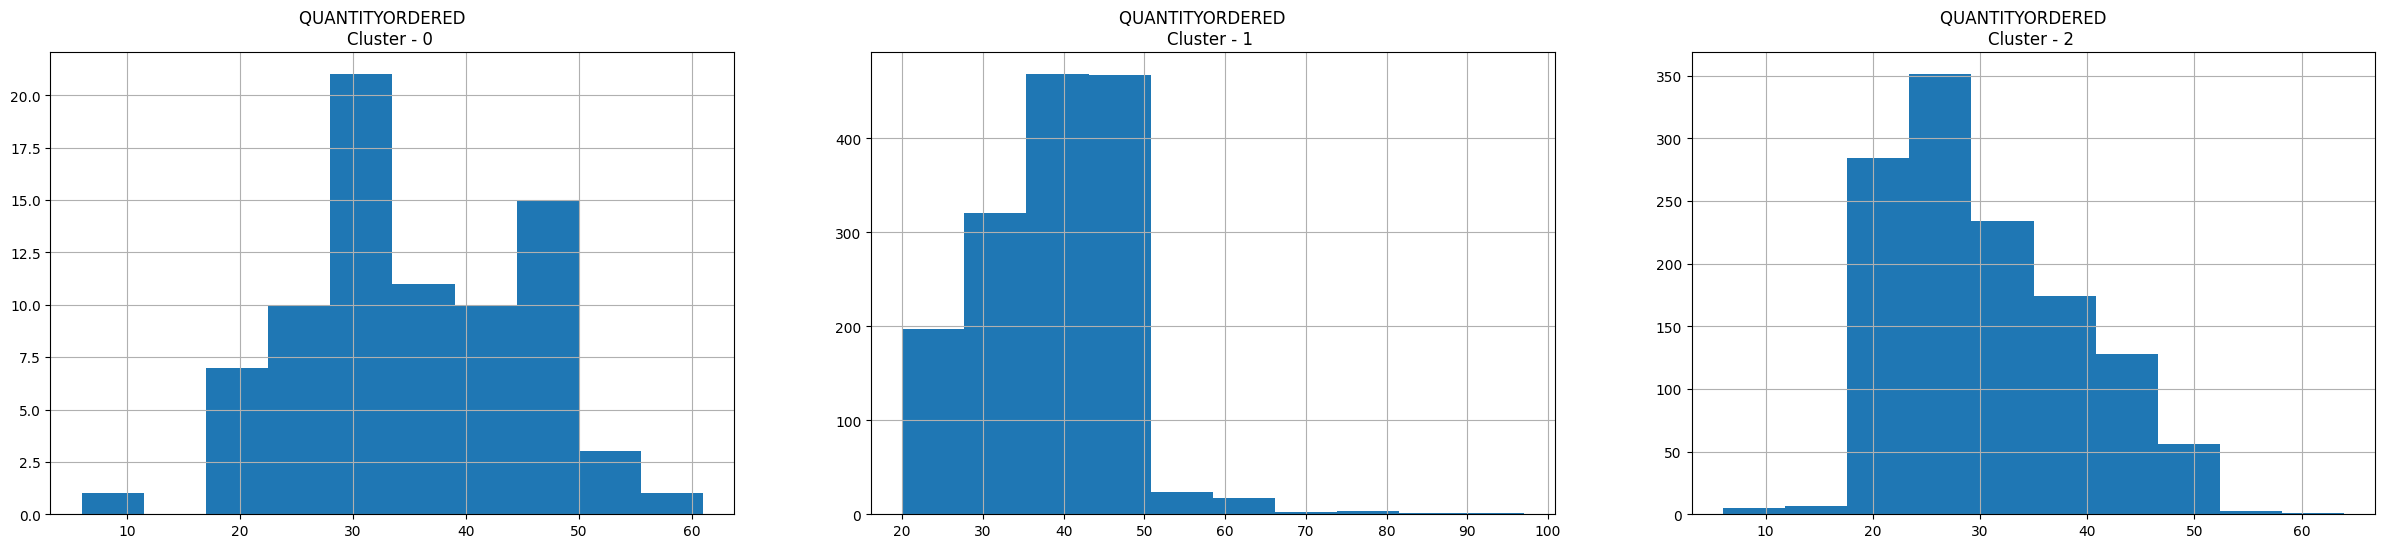

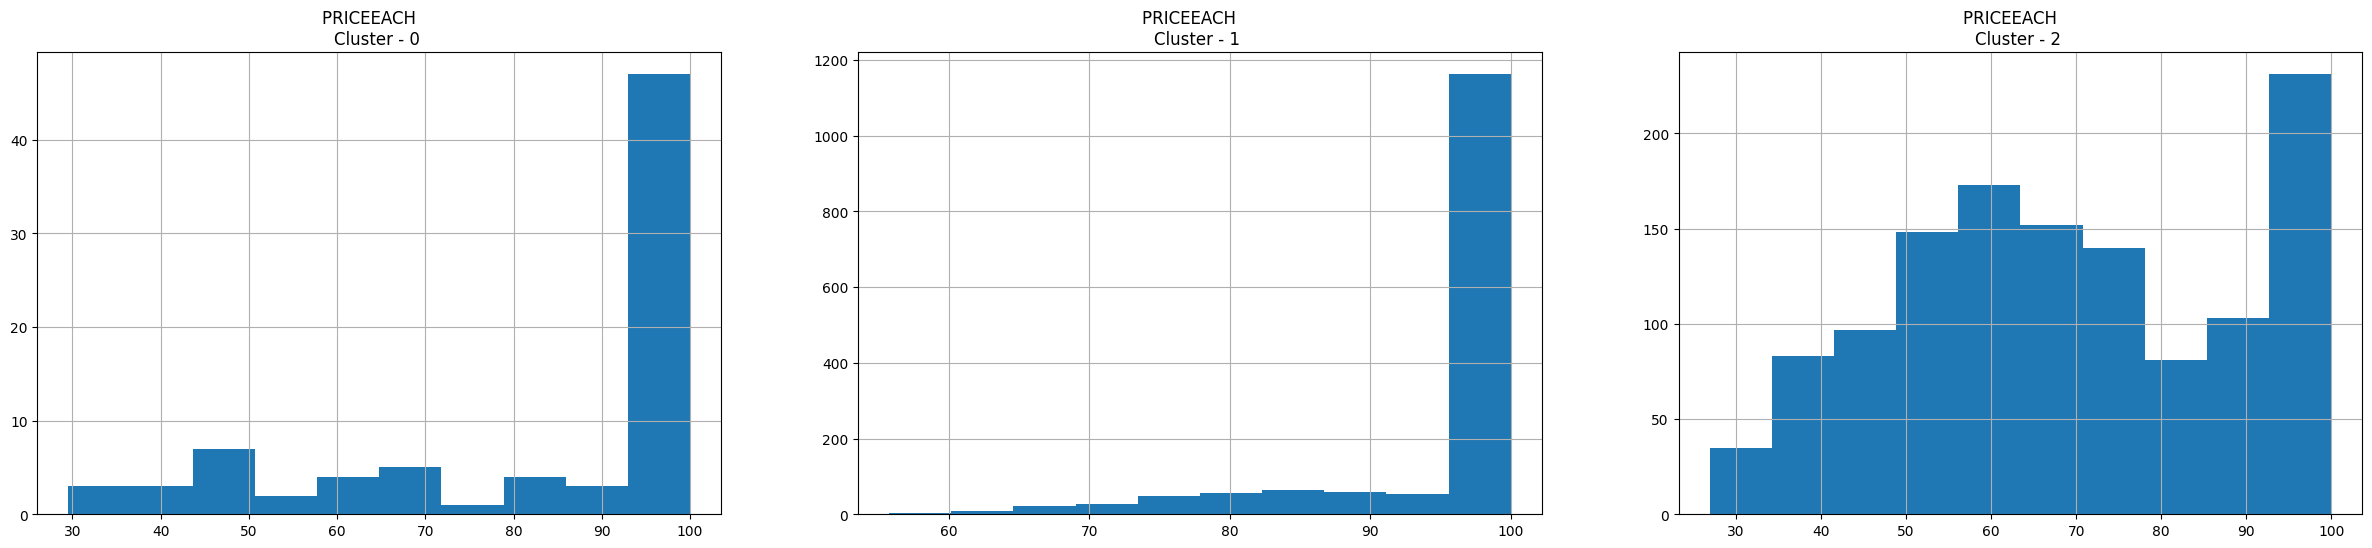

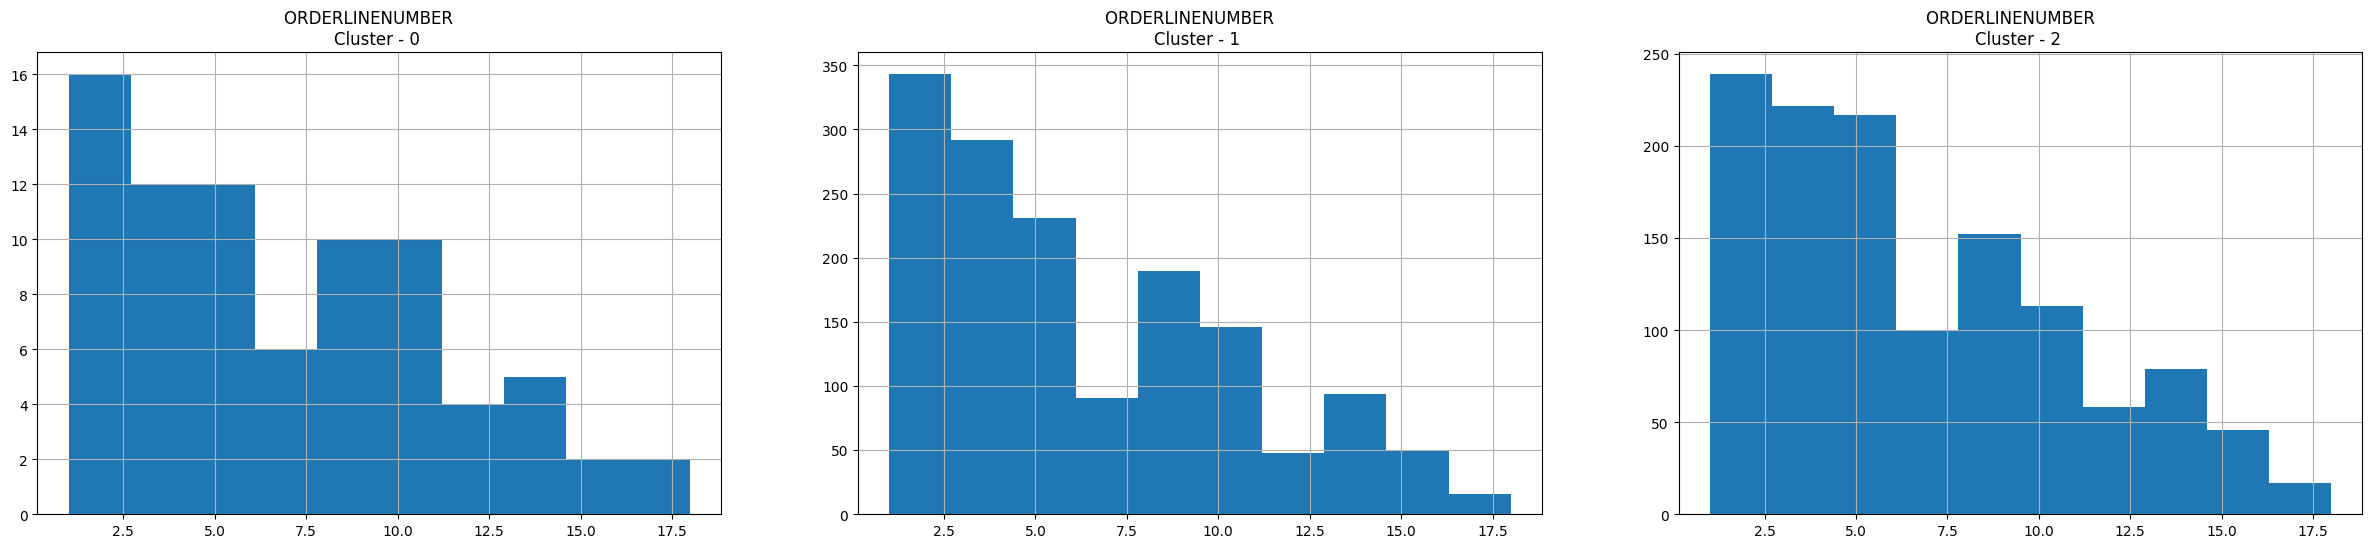

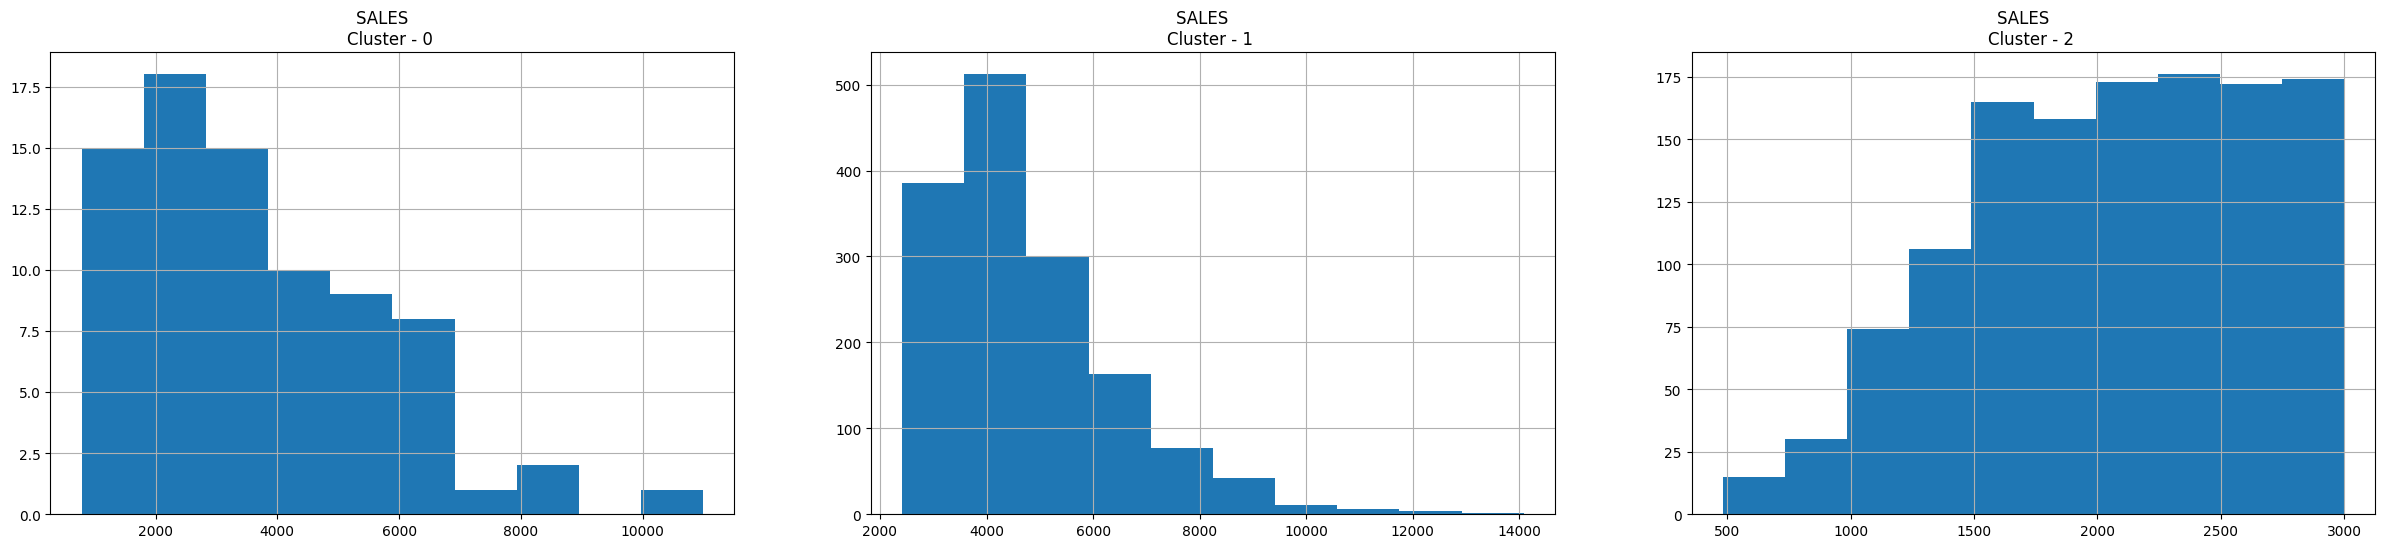

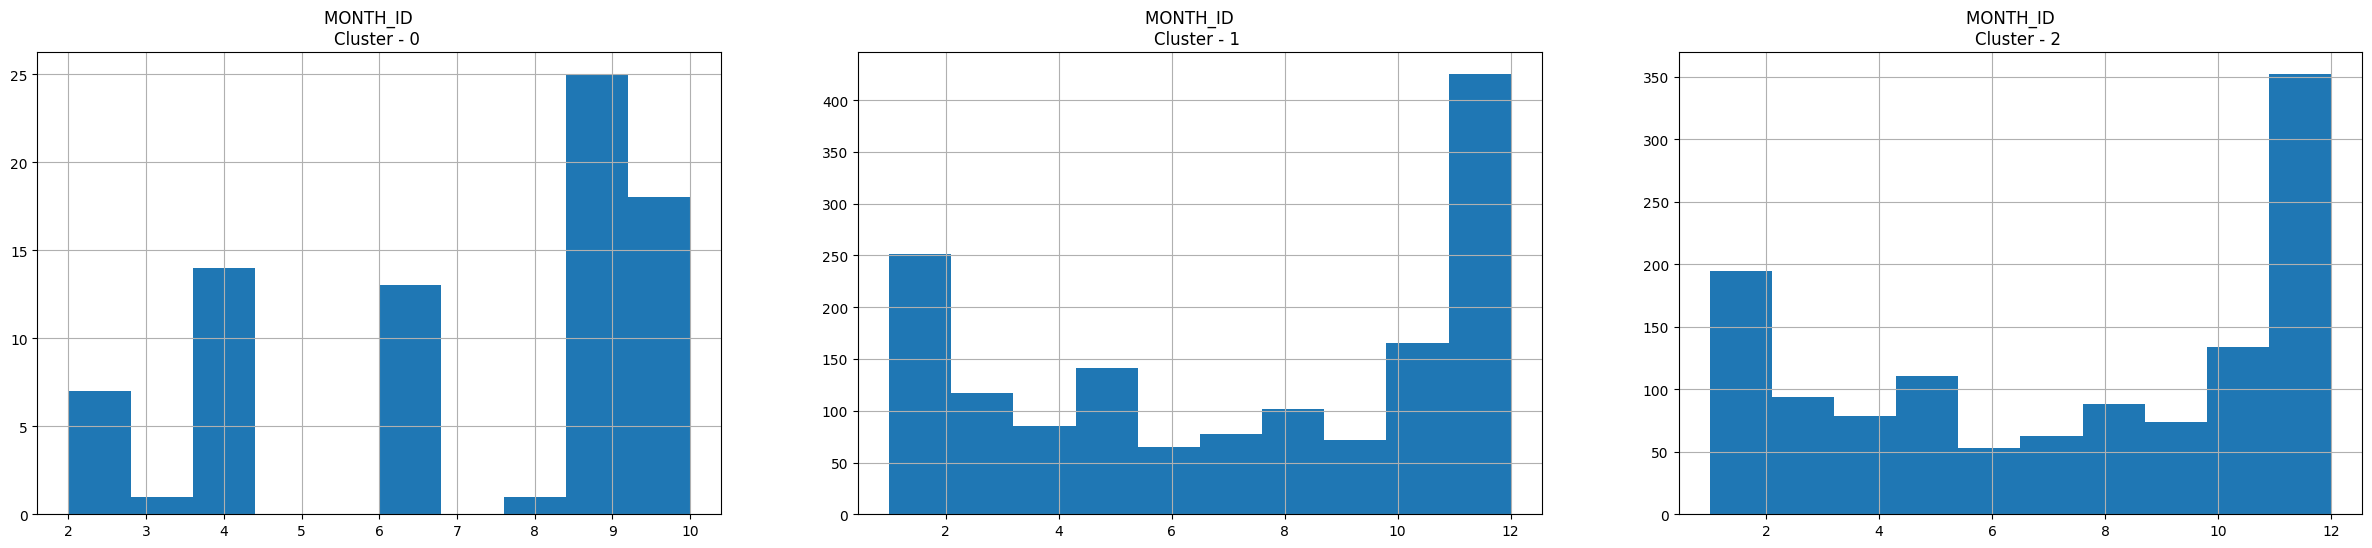

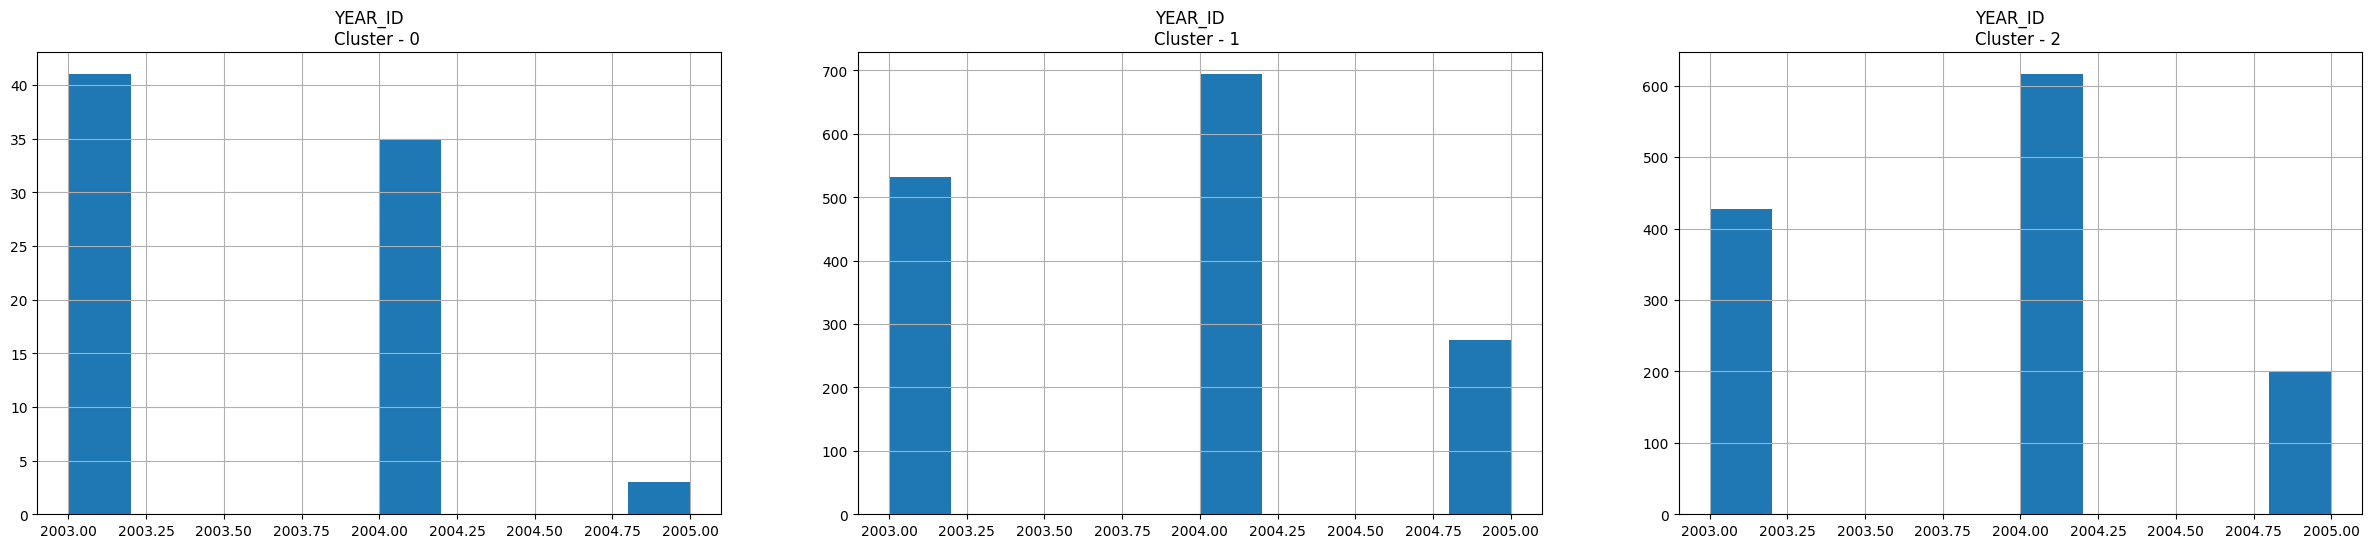

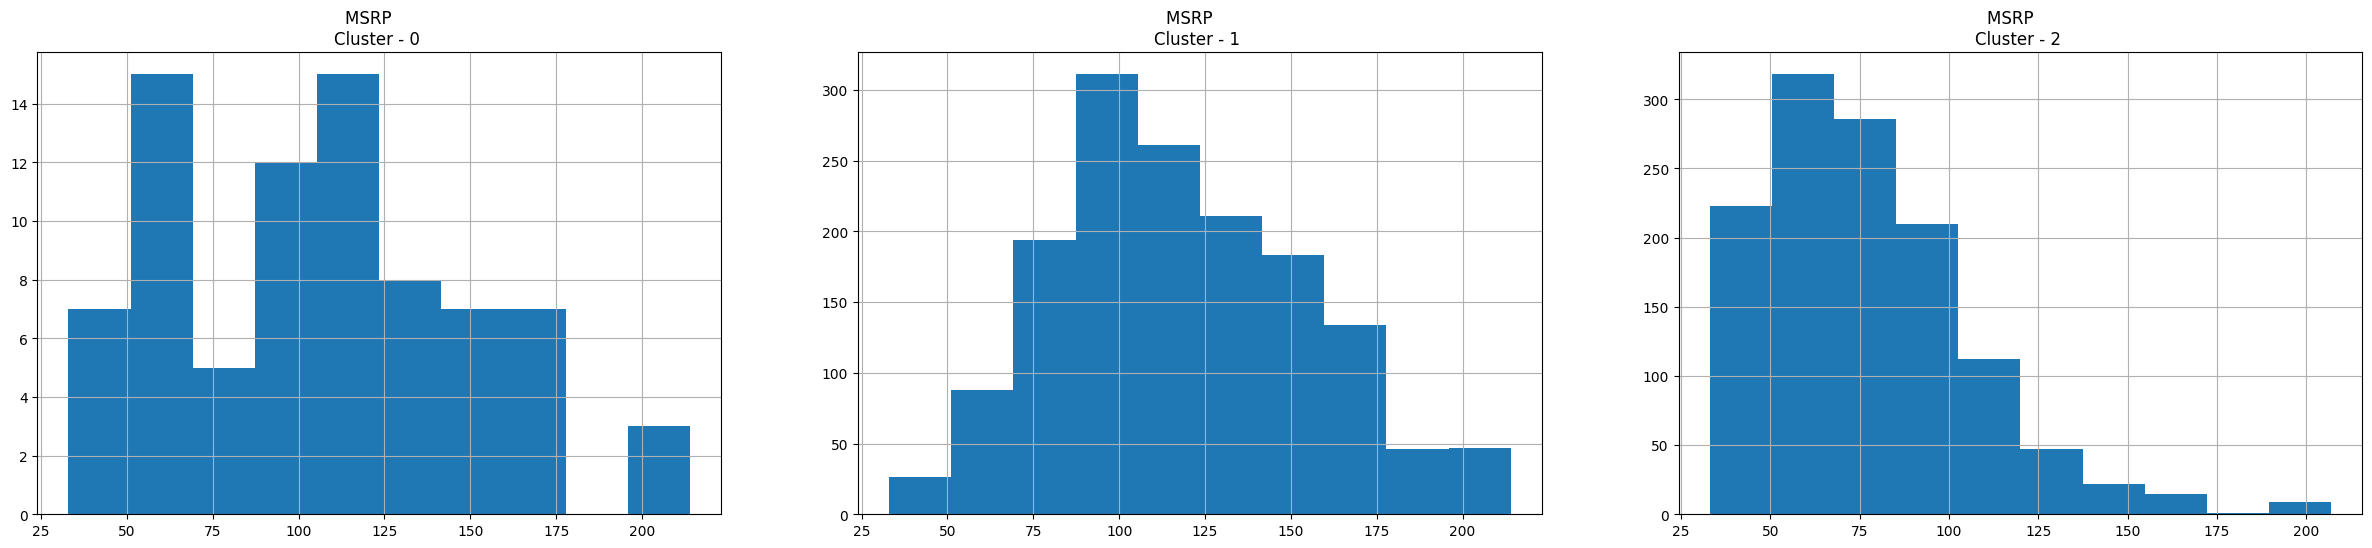

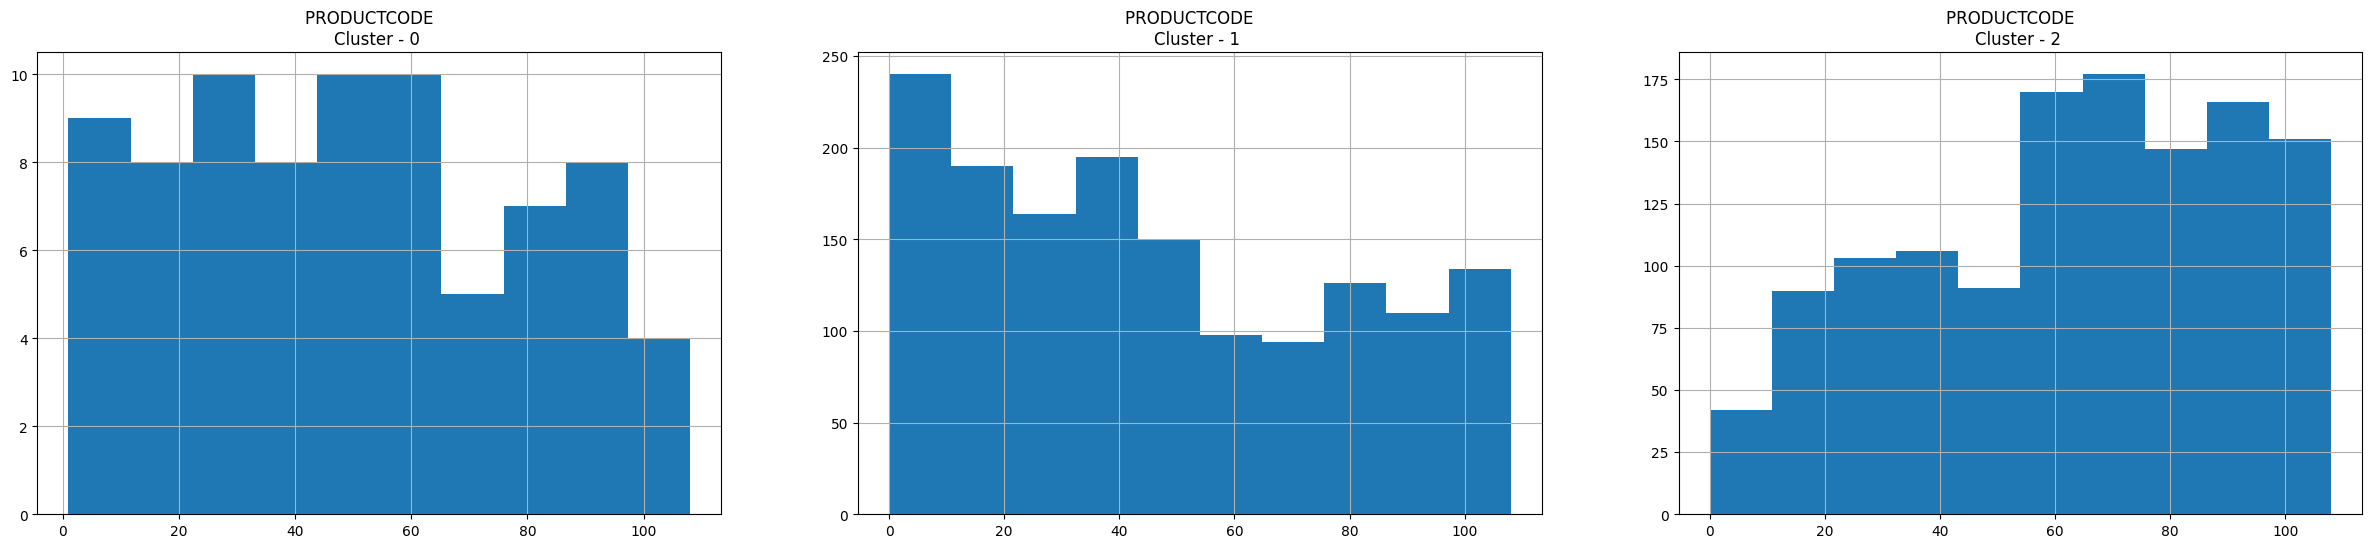

In [86]:
for i in sales_df.columns[:8]:
  plt.figure(figsize = (30, 6))
  for j in range(3):
    plt.subplot(1, 3, j+1)
    cluster = sale_df_cluster[sale_df_cluster['cluster'] == j]
    cluster[i].hist()
    plt.title('{}    \nCluster - {} '.format(i,j))

  plt.show()

In [87]:
pca = PCA(n_components = 3)
pca_sales = pca.fit_transform(sales_df_scaled)
pca_df = pd.DataFrame(data = pca_sales, columns = ['pca1', 'pca2', 'pca3'])
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster':labels.flatten()})], axis = 1)

In [88]:
fig = px.scatter_3d(pca_df, x = 'pca1', y = 'pca2', z = 'pca3', color = 'cluster', symbol = 'cluster', size_max = 18, opacity = 0.7)
fig.update_layout(margin = dict(l = 0, r = 0, b = 0, t = 0))